# Prior visualisation — LGD (Loss Given Default)

What our synthetic prior produces for **LGD**, next to the unmodified TabICL
prior, and next to the real datasets.

The quantity that matters here is **boundary mass — the share of targets sitting EXACTLY at 0 or 1**.

Real LGD has point masses at both ends: a fully-recovered loan loses exactly
0, a written-off one exactly 1. The original TabICL prior standard-scales its
target, so it puts essentially nothing inside [0,1] and produces atoms only by
chance ties. **This gap is why the project exists.**

Measured across all 7 LGD datasets: boundary mass runs from **1.8%**
(`lgd_lendingclub`) to **73%** (`heloc`) — a factor of forty. So the prior has
to span a *range*; matching any one dataset would be overfitting to it.

### How the prior does it

Our prior derives LGD from credit economics rather than shaping its marginal:

| mechanism | what it is |
|---|---|
| `collateral` | `LGD = clip(1 - [coverage x (1-haircut) - costs])`. Atoms at 0 from over-collateralisation, at 1 from unsecured facilities. |
| `workout` | recovery as a discounted, censored cashflow stream. A slow full recovery *is* a loss. |
| `segment_mixture` | secured / unsecured sub-books, so bimodality is a genuine mixture. |

The boundary atoms are therefore a **consequence** of the loan economics, not a
parameter someone set.

### How to read this notebook

Right now there are **two** priors per task: `original` (unmodified TabICL, the control)
and `credit_v1` (ours). Everything below discovers whatever variants exist, so adding a
`credit_v2` needs no edit here.

By default it generates **500 datasets per prior locally** to show the structure. That is
plenty for every plot — it is not the pool the model trains on, and the notebook says so.

The companion notebooks are `prior_visualisation_pd.ipynb` (the other task) and
`data_exploration.ipynb` (the real datasets these are aimed at).

All logic lives in `src/visualize/`; this notebook holds none. **It ends with a text
summary you can copy straight into a message.**

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from src.visualize import figures, pool_plots as pp, prior_plots, style, summaries

style.use_style()   # ONE shared style: identical colours in every notebook
pd.set_option("display.width", 200, "display.max_columns", 40)

TASK  = "lgd"
N     = 500     # datasets to draw per prior — enough to show the structure
FOCUS = None    # variant for the detail plots; None = the first non-original one

# Clears THIS notebook's figure folder — and no other — BEFORE anything is
# drawn, then saves every figure as PDF (print) + PNG (committable). Identical
# behaviour in Jupyter and under scripts/run_notebooks.py.
FIGS = figures.for_notebook("prior_visualisation_lgd")

### What the colours mean

`original` is always grey (the control) and our prior is always blue, in **every** figure
in this notebook and its sibling — so you never have to re-read a legend.

findfont: Failed to find font weight semibold, now using 700.


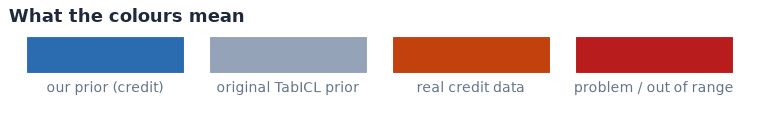

In [2]:
FIGS.save(style.show_palette(), "palette");

## 1. Which priors are on this machine?

`COMPLETE` means the whole pool the model trained on. `SAMPLE` means a partial copy —
fine for every plot here, but never quote it as "the pool".

If nothing is found, the next cell **generates the two arms live** and labels them
`(live)`. That is the normal path on a laptop.

In [3]:
variants = pp.discover_pools(TASK)
print(f"pools found: {variants or 'none — will generate live'}")
pp.describe_pools(TASK) if variants else None

pools found: none — will generate live


## 2. Draw the datasets

Same seed for every variant, so the draws are comparable rather than independently lucky.

In [4]:
loaded, SOURCE = pp.load_variants_or_generate(TASK, n=N, seed=0)
print(f"source = {SOURCE}")
print({k: len(v) for k, v in loaded.items()})

if FOCUS is None or FOCUS not in loaded:
    non_original = [v for v in loaded if not v.startswith("original")]
    FOCUS = non_original[0] if non_original else list(loaded)[0]
print(f"FOCUS (detail plots) = {FOCUS}")

REFERENCE = pp.real_reference(TASK)

no pools found for lgd — generating 500 datasets per arm live from config/LGD.yaml
source = live
{'original (live)': 500, 'credit (live)': 500}
FOCUS (detail plots) = credit (live)
reference: measured from 7 real LGD datasets


## 3. The summary table

One row per prior. For LGD the columns that matter are the ones about
boundary mass.

Expect `original` and `credit_v1` to differ sharply. If they look the same, something is
wrong with the generation, not with the plot.

In [5]:
pp.variant_summary(loaded, TASK)

,variant,n_sampled,rows_median,features_median,"in [0,1]",boundary mass mean,boundary p10,boundary p90,any atoms
0,original (live),500,778,26,0.004,0.0940,0.0023,0.3034,0.350
1,credit (live),500,775,35,1.000,0.3684,0.0399,0.6996,0.928


## 4. The key comparison

The question to ask is **does our prior's cloud actually cover where the real datasets
sit** — not merely "is it different from the original".

Reference values are measured from your processed datasets when they are present, and
fall back to recorded values otherwise (the output says which).

findfont: Failed to find font weight semibold, now using 700.


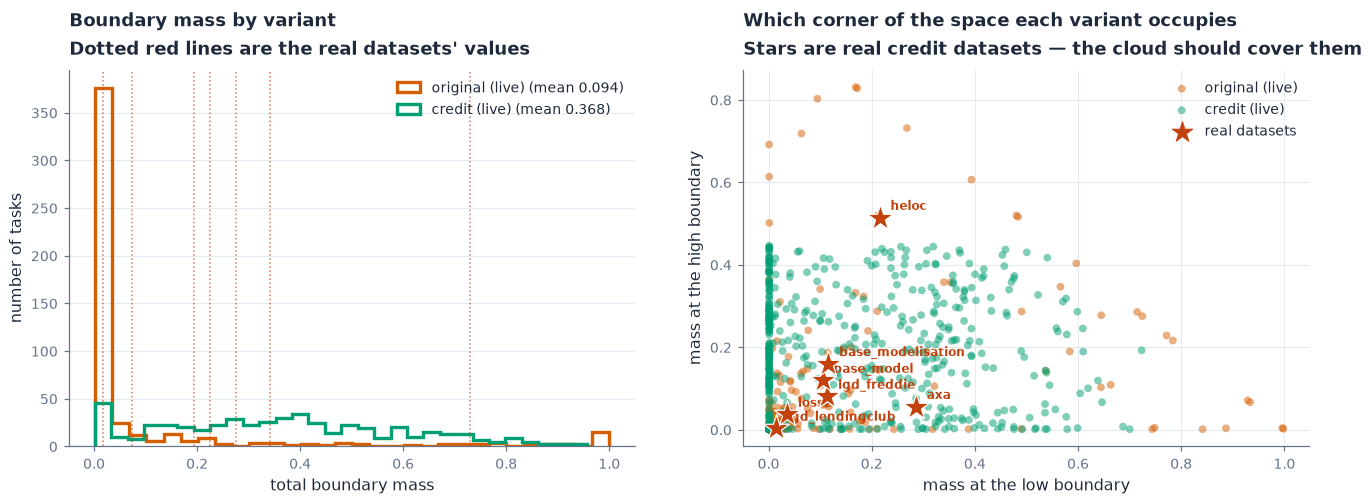

In [6]:
FIGS.save(pp.plot_target_comparison(loaded, TASK, reference=REFERENCE), "target_comparison");

## 5. Target shapes, one row per prior

Ten histograms per variant. Look for **variety** within a row: a prior that always
produces the same shape will fit one real dataset and fail on the others, and that
failure is invisible in a mean.

findfont: Failed to find font weight semibold, now using 700.


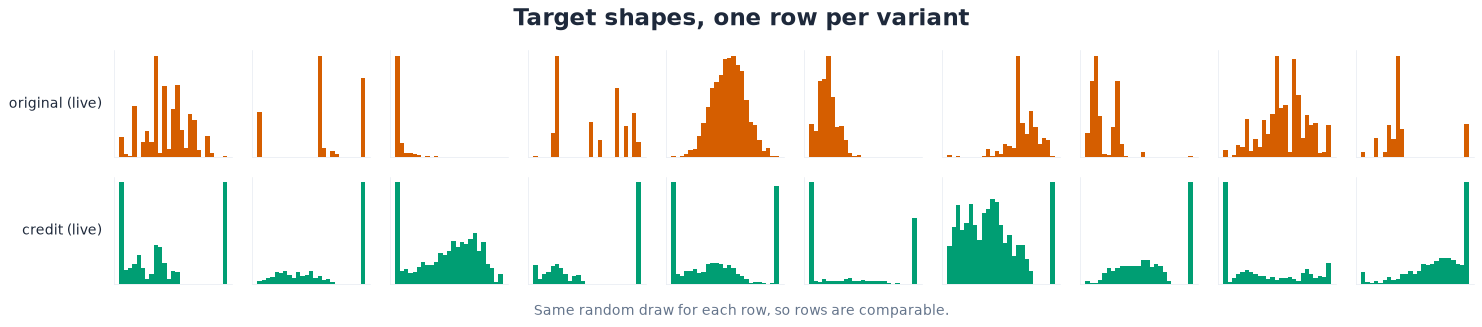

In [7]:
FIGS.save(pp.plot_target_shapes_by_variant(loaded, n_per=10), "target_shapes_by_variant");

## 6. Feature dependence

O'Prior's central claim is that what a prior teaches is a **dependence structure**, not
individual functions. Bold lines are medians.

If two variants' spectra sit on top of each other they teach a similar structure
*however different their targets look* — which would be an important negative result,
not a boring one.

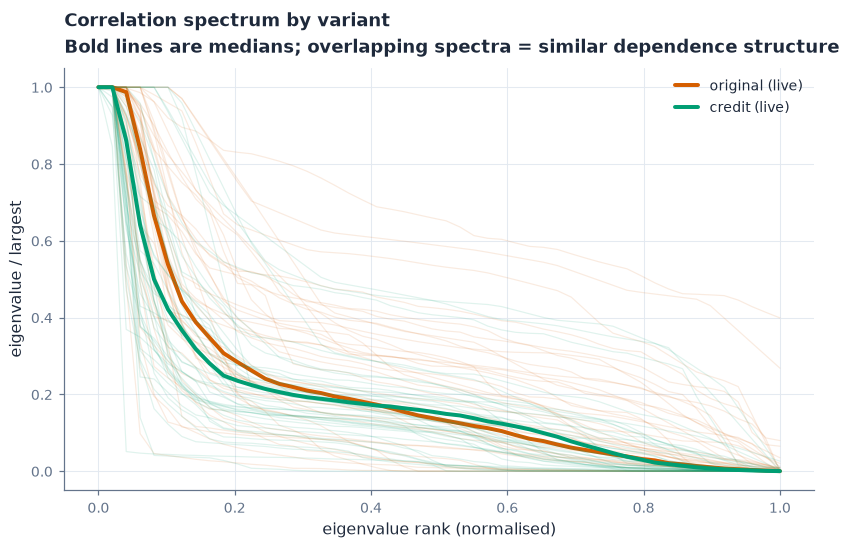

In [8]:
FIGS.save(pp.plot_spectrum_by_variant(loaded), "spectrum_by_variant");

## 7. Shape sanity check

All variants should look **the same** here. Table shape is not what we are changing, so a
visible difference means an accidental confound rather than a finding.

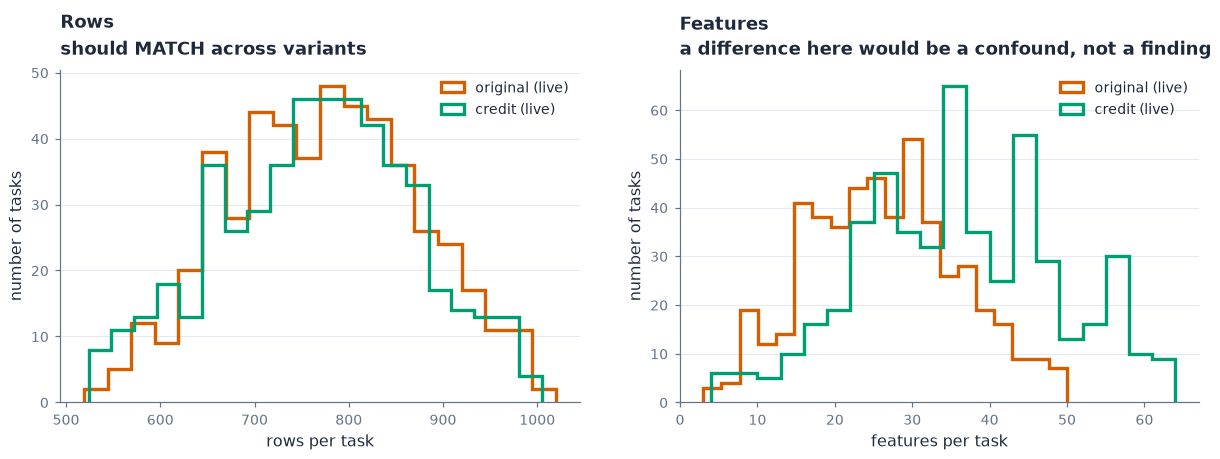

In [9]:
FIGS.save(pp.plot_shapes_by_variant(loaded), "shapes_by_variant");

## 8. One prior up close

Everything below uses `FOCUS` only — these are the plots that cannot be stacked across
variants. Change `FOCUS` in the setup cell and re-run this section to inspect another.

credit (live): 500 datasets


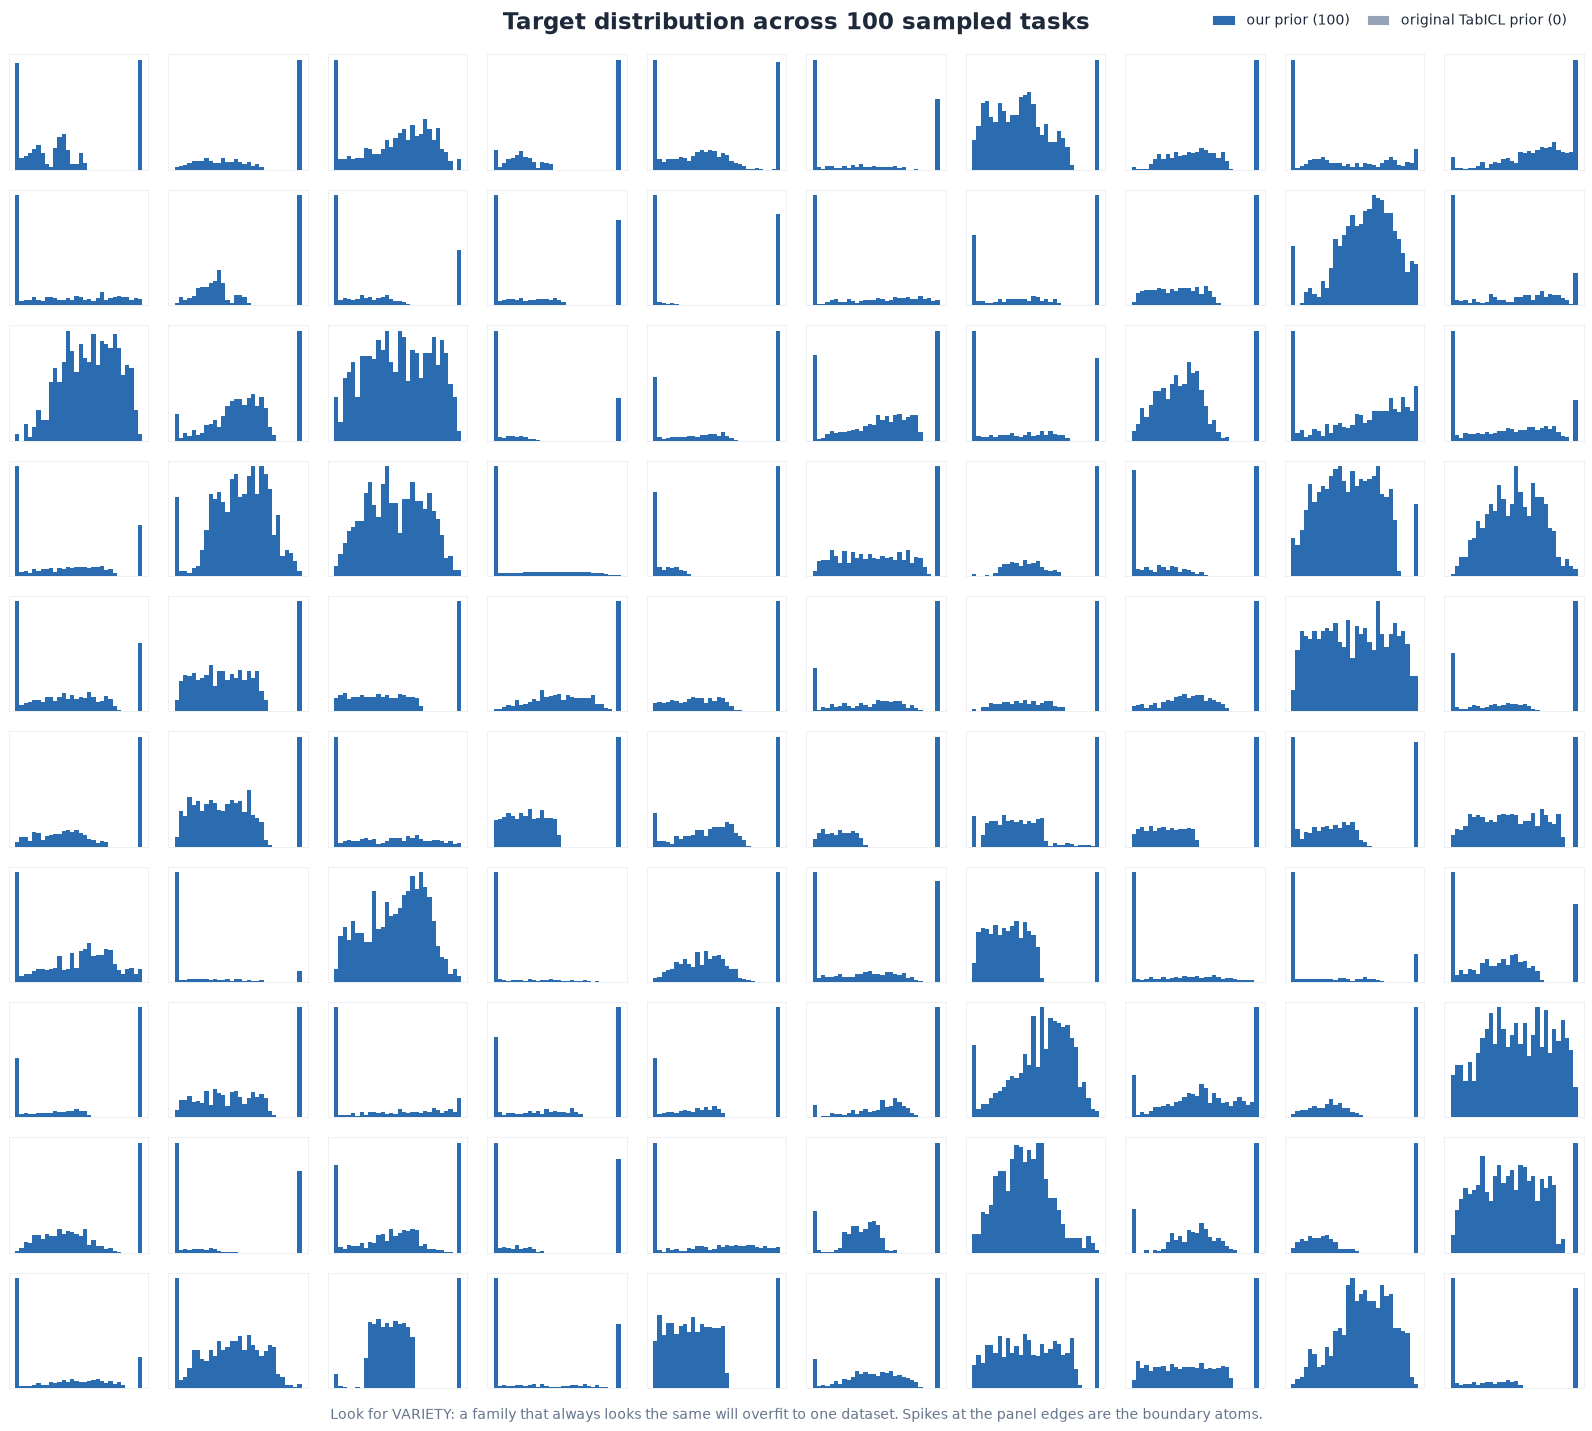

In [10]:
focus_tasks = loaded[FOCUS]
print(f"{FOCUS}: {len(focus_tasks)} datasets")
fig = prior_plots.plot_target_grid(focus_tasks, n_show=min(100, len(focus_tasks)))

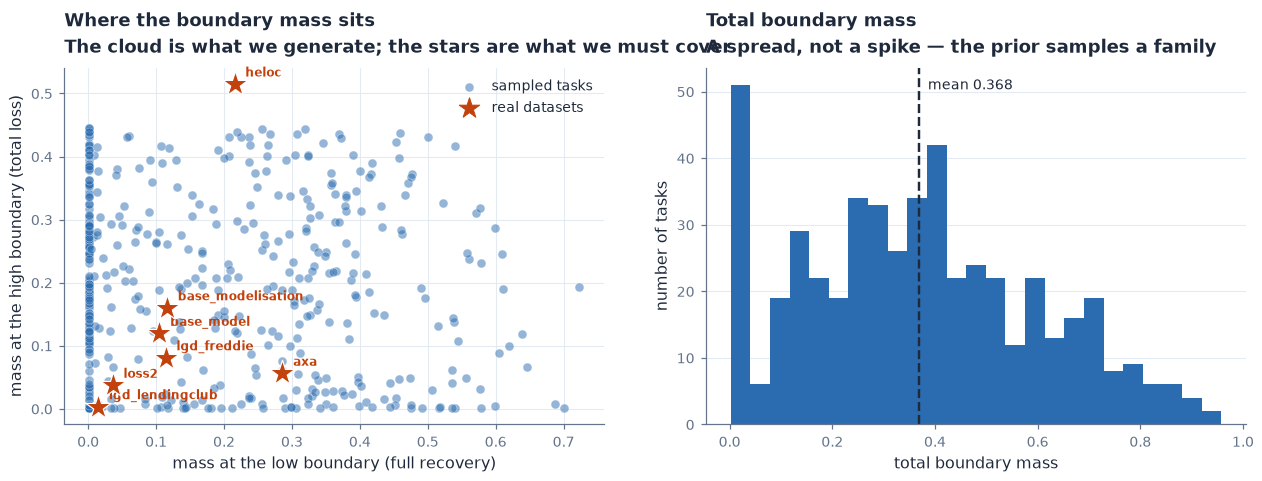

In [11]:
FIGS.save(prior_plots.plot_boundary_mass(focus_tasks, real_reference=REFERENCE), "boundary_mass");

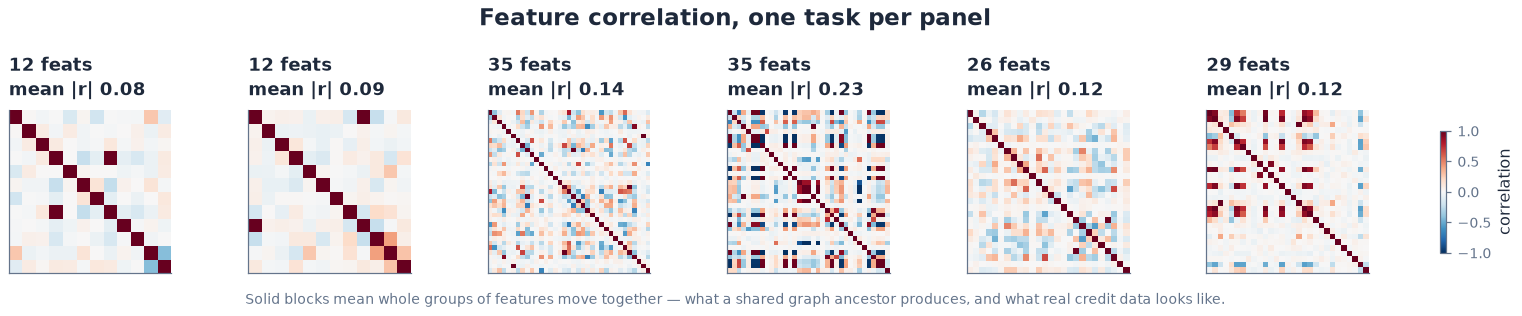

In [12]:
FIGS.save(prior_plots.plot_feature_relationships(focus_tasks, n_show=6), "feature_relationships");

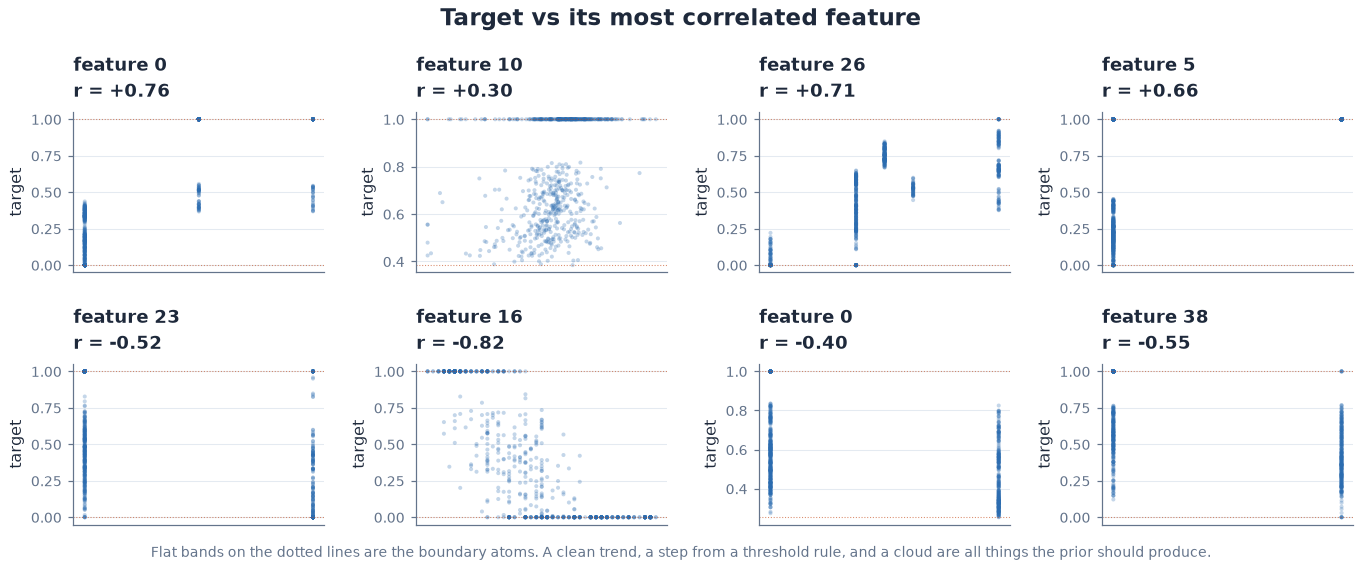

In [13]:
FIGS.save(prior_plots.plot_feature_target_relation(focus_tasks, n_show=8), "feature_target_relation");

## 9. Save the figures (optional)

`results/_local/` is gitignored — regenerate rather than commit.

---

## 10. TEXT SUMMARY

Everything above, as text. **Copy-paste this** — it carries the numbers, which the
figures do not.

In [15]:
print(summaries.prior_summary(loaded, TASK, source=SOURCE, reference=REFERENCE))
print()
print(FIGS.summary())


PRIOR SUMMARY — LGD
data source      : live  ('pool' = the files training reads; 'live' = generated on the fly now)
variants compared: original (live), credit (live)
datasets sampled : original (live)=500, credit (live)=500

--- PER VARIANT --------------------------------------------------------------

original (live):
  shape          rows 519 to 1020 (median 778) | features 3 to 50 (median 26)
  in [0,1]       0.4% of datasets
  boundary mass  0.2% to 100.0% (median 0.3%)
    at 0 (full recovery) mean 5.3%
    at 1 (total loss)    mean 4.1%
  any atoms      35.0% of datasets

credit (live):
  shape          rows 524 to 1005 (median 775) | features 4 to 64 (median 35)
  in [0,1]       100.0% of datasets
  boundary mass  0.2% to 95.8% (median 35.8%)
    at 0 (full recovery) mean 17.9%
    at 1 (total loss)    mean 18.9%
  any atoms      92.8% of datasets

--- AGAINST THE REAL DATASETS ------------------------------------------------
real boundary mass: axa=34.2%, base_model=22.4%, ba